# 04 - Explicabilidad y métricas de negocio

## Predicción del riesgo de rotura de stock en un entorno logístico

Este notebook completa la fase de evaluación del proyecto incorporando dos componentes clave:

1. **Explicabilidad del modelo**, para identificar qué variables influyen más en la predicción del riesgo de stockout.
2. **Traducción de métricas técnicas a métricas de negocio**, para estimar el valor potencial del modelo en un contexto logístico.

El objetivo no es afirmar que el modelo resuelve completamente el problema, sino analizar si sus predicciones pueden ser útiles para priorizar alertas y reducir el impacto operativo de posibles roturas de stock.

## 1. Importación de librerías

Se cargan las librerías necesarias para análisis, visualización, evaluación, explicabilidad y lectura del modelo previamente entrenado.

In [1]:
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    classification_report
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 2. Definición de rutas

Este notebook parte de los artefactos generados en `03_model_training.ipynb`:

- Modelo final entrenado.
- Lista de variables utilizadas.
- Predicciones sobre el conjunto de test.
- Dataset procesado.

In [2]:
DATA_PATH = "../data/processed/stockout_dataset.csv"
MODEL_PATH = "../models/best_stockout_model.pkl"
FEATURES_PATH = "../models/model_features.json"
PREDICTIONS_PATH = "../outputs/test_predictions_best_model.csv"

OUTPUT_METRICS_DIR = "../outputs/metrics"
OUTPUT_FIGURES_DIR = "../outputs/figures"
OUTPUT_REPORTS_DIR = "../outputs/reports"

os.makedirs(OUTPUT_METRICS_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUT_REPORTS_DIR, exist_ok=True)

## 3. Carga de modelo, features y predicciones

Se cargan los resultados del notebook anterior. Si alguno de estos archivos no existe, primero debe ejecutarse `03_model_training.ipynb` completo.

In [3]:
model = joblib.load(MODEL_PATH)

with open(FEATURES_PATH, "r", encoding="utf-8") as f:
    model_features = json.load(f)

predictions = pd.read_csv(PREDICTIONS_PATH)

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print("Modelo cargado:", type(model))
print("Número de features:", len(model_features))
print("Predicciones:", predictions.shape)
print("Dataset procesado:", df.shape)

predictions.head()

Modelo cargado: <class 'sklearn.pipeline.Pipeline'>
Número de features: 18
Predicciones: (892500, 6)
Dataset procesado: (4472500, 25)


,store_id,item_id,date,y_true,y_pred,y_proba
0,store_27,item_5,2023-01-02,1,1,0.579459
1,store_29,item_37,2023-01-02,1,1,0.611521
2,store_46,item_20,2023-01-02,0,1,0.581733
3,store_43,item_8,2023-01-02,1,1,0.558664
4,store_30,item_49,2023-01-02,1,1,0.587411


## 4. Revisión de columnas disponibles

El archivo de predicciones debe contener, al menos:

- `y_true`: valor real.
- `y_pred`: predicción binaria.
- `y_proba`: probabilidad estimada de riesgo de stockout.

En caso de que los nombres generados por el notebook anterior sean distintos, esta celda intenta normalizarlos.

In [4]:
print("Columnas originales del archivo de predicciones:")
print(predictions.columns.tolist())

# Normalización defensiva de nombres de columnas.
# El notebook 03 puede guardar el valor real como "y_true" o, si viene de una versión anterior, como "stockout_risk".
rename_map = {}

possible_y_true_cols = ["y_true", "stockout_risk", "target", "actual", "real"]
possible_y_pred_cols = ["y_pred", "prediction", "predicted", "pred"]
possible_y_proba_cols = ["y_proba", "probability", "proba", "predicted_probability", "risk_probability"]

if "y_true" not in predictions.columns:
    for col in possible_y_true_cols:
        if col in predictions.columns:
            rename_map[col] = "y_true"
            break

if "y_pred" not in predictions.columns:
    for col in possible_y_pred_cols:
        if col in predictions.columns:
            rename_map[col] = "y_pred"
            break

if "y_proba" not in predictions.columns:
    for col in possible_y_proba_cols:
        if col in predictions.columns:
            rename_map[col] = "y_proba"
            break

predictions = predictions.rename(columns=rename_map)

print("\nColumnas después de normalizar:")
print(predictions.columns.tolist())

required_cols = ["y_true", "y_pred", "y_proba"]
missing_cols = [col for col in required_cols if col not in predictions.columns]

if missing_cols:
    raise ValueError(
        "Faltan columnas obligatorias en el archivo de predicciones: "
        f"{missing_cols}. Revisa que el notebook 03 guarde y_true, y_pred e y_proba."
    )

predictions[required_cols].head()

Columnas originales del archivo de predicciones:
['store_id', 'item_id', 'date', 'y_true', 'y_pred', 'y_proba']

Columnas después de normalizar:
['store_id', 'item_id', 'date', 'y_true', 'y_pred', 'y_proba']


,y_true,y_pred,y_proba
0,1,1,0.579459
1,1,1,0.611521
2,0,1,0.581733
3,1,1,0.558664
4,1,1,0.587411


## 5. Evaluación del modelo final

Antes de analizar el impacto de negocio, se recalculan las métricas técnicas principales sobre el conjunto de test.

In [5]:
y_true = predictions["y_true"]
y_pred = predictions["y_pred"]
y_proba = predictions["y_proba"]

final_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1_score": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_proba)
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv(f"{OUTPUT_METRICS_DIR}/final_model_metrics.csv", index=False)
final_metrics_df

,accuracy,precision,recall,f1_score,roc_auc
0,0.57252,0.635124,0.606733,0.620604,0.589043


In [6]:
print(classification_report(y_true, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.50      0.53      0.51    378198
           1       0.64      0.61      0.62    514302

    accuracy                           0.57    892500
   macro avg       0.57      0.57      0.57    892500
weighted avg       0.58      0.57      0.57    892500



## 6. Matriz de confusión del modelo final

La matriz de confusión permite interpretar el comportamiento operativo del modelo:

- **True Positives (TP)**: stockouts detectados correctamente.
- **False Positives (FP)**: alertas generadas cuando no había stockout.
- **False Negatives (FN)**: stockouts no detectados.
- **True Negatives (TN)**: casos sin riesgo identificados correctamente.

En un contexto logístico, los falsos negativos suelen ser especialmente relevantes porque representan roturas de stock no anticipadas.

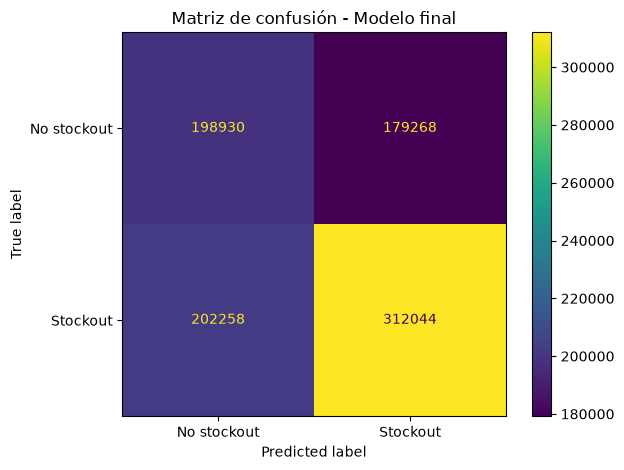

,metric,value,business_interpretation
0,TN,198930,Casos sin stockout correctamente descartados
1,FP,179268,Alertas falsas que generarían revisión operativa
2,FN,202258,Stockouts reales no detectados por el modelo
3,TP,312044,Stockouts correctamente anticipados


In [7]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No stockout", "Stockout"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - Modelo final")
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIGURES_DIR}/final_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

TN, FP, FN, TP = cm.ravel()

confusion_summary = pd.DataFrame({
    "metric": ["TN", "FP", "FN", "TP"],
    "value": [TN, FP, FN, TP],
    "business_interpretation": [
        "Casos sin stockout correctamente descartados",
        "Alertas falsas que generarían revisión operativa",
        "Stockouts reales no detectados por el modelo",
        "Stockouts correctamente anticipados"
    ]
})

confusion_summary.to_csv(f"{OUTPUT_METRICS_DIR}/confusion_summary.csv", index=False)
confusion_summary

## 7. Importancia de variables

Se analiza qué variables han tenido mayor peso en el modelo. Esta interpretación debe entenderse como una aproximación: la importancia de variables indica qué columnas contribuyen más al modelo, pero no implica causalidad directa.

In [8]:
# Extracción defensiva de importancia de variables
importance_values = None

if hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
elif hasattr(model, "named_steps"):
    # Si el modelo está dentro de un Pipeline, se intenta localizar el estimador final
    final_step = list(model.named_steps.values())[-1]
    if hasattr(final_step, "feature_importances_"):
        importance_values = final_step.feature_importances_
    elif hasattr(final_step, "coef_"):
        importance_values = np.abs(final_step.coef_[0])
elif hasattr(model, "coef_"):
    importance_values = np.abs(model.coef_[0])

if importance_values is None:
    print("El modelo no expone importancias de variables de forma directa.")
    feature_importance_df = pd.DataFrame(columns=["feature", "importance"])
else:
    feature_importance_df = pd.DataFrame({
        "feature": model_features,
        "importance": importance_values
    }).sort_values("importance", ascending=False)
    
    feature_importance_df.to_csv(f"{OUTPUT_METRICS_DIR}/feature_importance.csv", index=False)

feature_importance_df.head(20)

,feature,importance
13,rolling_mean_14,1.619354
14,rolling_mean_30,0.902387
12,rolling_mean_7,0.852960
0,sales,0.379696
16,trend_7_30,0.223457
10,sales_lag_14,0.112159
2,promo,0.107487
9,sales_lag_7,0.103784
7,week,0.067485
11,sales_lag_30,0.055851


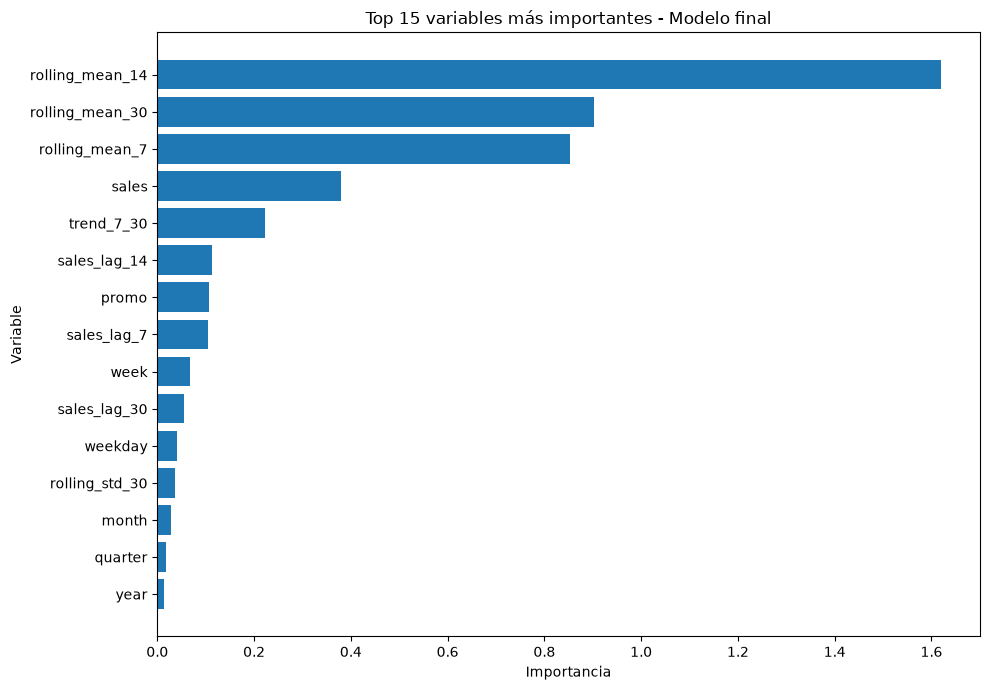

In [9]:
if not feature_importance_df.empty:
    top_n = 15
    plot_df = feature_importance_df.head(top_n).sort_values("importance")
    
    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(f"Top {top_n} variables más importantes - Modelo final")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIGURES_DIR}/final_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Explicabilidad con SHAP opcional

SHAP permite analizar el efecto de cada variable sobre las predicciones. Esta sección está preparada para ejecutarse si la librería `shap` está instalada.

Para evitar tiempos de ejecución excesivos, se utiliza una muestra del conjunto de test.

In [10]:
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("SHAP no está instalado. Esta sección se omite sin afectar al resto del análisis.")

In [11]:
if shap_available:
    # Reconstrucción del conjunto de test mediante el mismo corte temporal usado en model_training
    df_sorted = df.sort_values("date").reset_index(drop=True)
    cutoff_date = df_sorted["date"].quantile(0.8)
    test_df = df_sorted[df_sorted["date"] > cutoff_date].copy()
    X_test = test_df[model_features]
    
    sample_size = min(5000, len(X_test))
    X_sample = X_test.sample(sample_size, random_state=42)
    
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        
        shap.summary_plot(shap_values, X_sample, show=False)
        plt.title("SHAP summary plot - Modelo final")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_FIGURES_DIR}/shap_summary_plot.png", dpi=150, bbox_inches="tight")
        plt.show()
        
    except Exception as e:
        print("No se pudo calcular SHAP directamente sobre el modelo:", e)
        print("El análisis de explicabilidad se mantiene con feature importance.")

No se pudo calcular SHAP directamente sobre el modelo: Model type not yet supported by TreeExplainer: <class 'sklearn.pipeline.Pipeline'>
El análisis de explicabilidad se mantiene con feature importance.


## 9. Análisis de umbrales de decisión

Por defecto, muchos modelos clasifican como positivo cuando la probabilidad es mayor o igual a 0.50. Sin embargo, en problemas de negocio el umbral puede ajustarse según el coste de los errores.

En este caso:

- Un umbral más bajo genera más alertas y suele aumentar el recall.
- Un umbral más alto reduce alertas falsas, pero puede dejar más stockouts sin detectar.

Este análisis ayuda a decidir un punto de equilibrio operativo.

In [12]:
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred_threshold),
        "precision": precision_score(y_true, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_true, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_true, y_pred_threshold, zero_division=0),
        "alerts_generated": int(tp + fp),
        "stockouts_detected": int(tp),
        "stockouts_missed": int(fn),
        "false_alerts": int(fp)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.to_csv(f"{OUTPUT_METRICS_DIR}/threshold_analysis.csv", index=False)
threshold_df.head()

,threshold,accuracy,precision,recall,f1_score,alerts_generated,stockouts_detected,stockouts_missed,false_alerts
0,0.10,0.576249,0.576249,1.000000,0.731165,892500,514302,0,378198
1,0.15,0.576260,0.576258,0.999967,0.731163,892456,514285,17,378171
2,0.20,0.576323,0.576322,0.999648,0.731130,892072,514121,181,377951
3,0.25,0.576632,0.576672,0.997706,0.730891,889798,513122,1180,376676
4,0.30,0.577746,0.578010,0.990039,0.729891,880918,509179,5123,371739


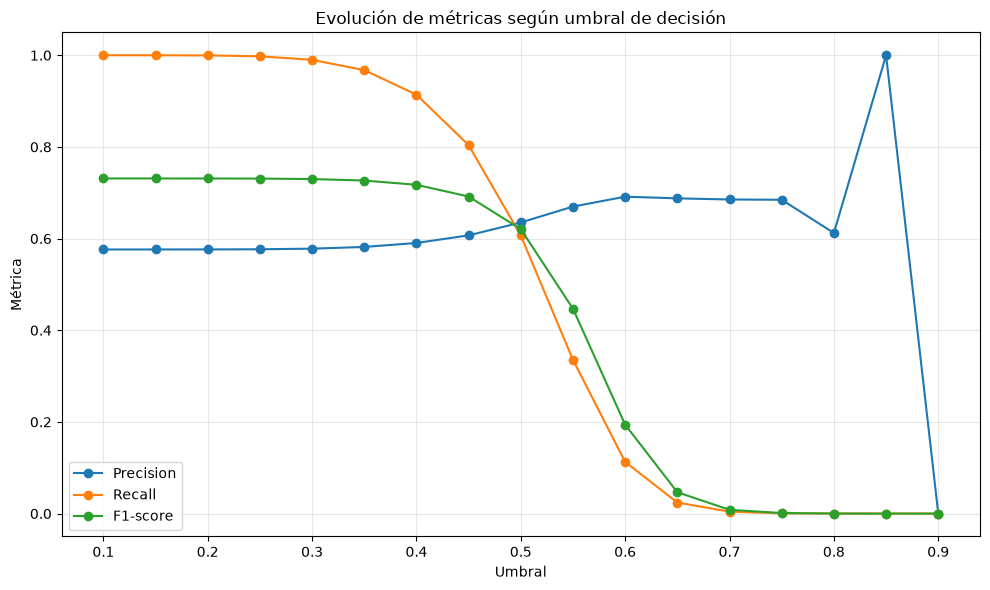

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], marker="o", label="F1-score")
plt.title("Evolución de métricas según umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIGURES_DIR}/threshold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

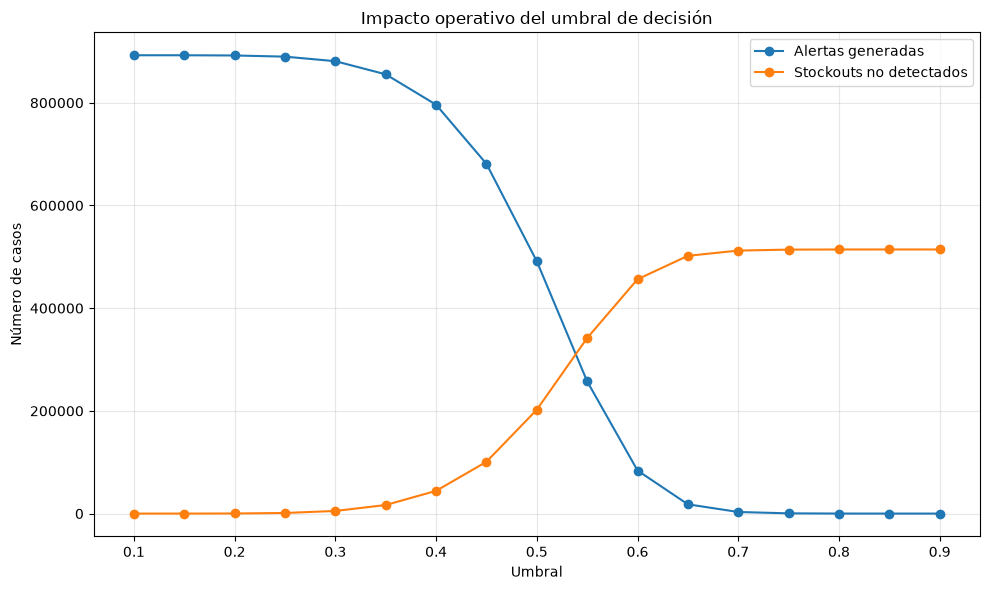

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["alerts_generated"], marker="o", label="Alertas generadas")
plt.plot(threshold_df["threshold"], threshold_df["stockouts_missed"], marker="o", label="Stockouts no detectados")
plt.title("Impacto operativo del umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Número de casos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIGURES_DIR}/threshold_business_impact.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Simulación de métricas de negocio

Como no se dispone de costes reales de la empresa, se plantea una simulación de escenarios.

Supuestos:

- **Coste de falso negativo**: impacto de no detectar una rotura de stock.
- **Coste de falso positivo**: coste operativo de revisar una alerta que finalmente no era stockout.

La simulación no pretende calcular un ahorro real definitivo, sino mostrar cómo el modelo podría evaluarse desde una perspectiva empresarial.

In [15]:
business_scenarios = [
    {
        "scenario": "Conservador",
        "cost_false_negative": 50,
        "cost_false_positive": 5
    },
    {
        "scenario": "Medio",
        "cost_false_negative": 100,
        "cost_false_positive": 10
    },
    {
        "scenario": "Alto impacto",
        "cost_false_negative": 200,
        "cost_false_positive": 15
    }
]

business_results = []

for scenario in business_scenarios:
    for threshold in thresholds:
        y_pred_threshold = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
        
        cost_fn = scenario["cost_false_negative"]
        cost_fp = scenario["cost_false_positive"]
        
        # Coste sin modelo: todos los stockouts reales llegan sin anticipación
        cost_without_model = (tp + fn) * cost_fn
        
        # Coste con modelo: se mantienen los FN y se asume coste de revisión para FP
        cost_with_model = (fn * cost_fn) + (fp * cost_fp)
        estimated_saving = cost_without_model - cost_with_model
        
        business_results.append({
            "scenario": scenario["scenario"],
            "threshold": threshold,
            "cost_false_negative": cost_fn,
            "cost_false_positive": cost_fp,
            "stockouts_detected": int(tp),
            "stockouts_missed": int(fn),
            "false_alerts": int(fp),
            "alerts_generated": int(tp + fp),
            "cost_without_model": float(cost_without_model),
            "cost_with_model": float(cost_with_model),
            "estimated_saving": float(estimated_saving)
        })

business_df = pd.DataFrame(business_results)
business_df.to_csv(f"{OUTPUT_METRICS_DIR}/business_scenarios.csv", index=False)
business_df.head()

,scenario,threshold,cost_false_negative,cost_false_positive,stockouts_detected,stockouts_missed,false_alerts,alerts_generated,cost_without_model,cost_with_model,estimated_saving
0,Conservador,0.10,50,5,514302,0,378198,892500,25715100.0,1890990.0,23824110.0
1,Conservador,0.15,50,5,514285,17,378171,892456,25715100.0,1891705.0,23823395.0
2,Conservador,0.20,50,5,514121,181,377951,892072,25715100.0,1898805.0,23816295.0
3,Conservador,0.25,50,5,513122,1180,376676,889798,25715100.0,1942380.0,23772720.0
4,Conservador,0.30,50,5,509179,5123,371739,880918,25715100.0,2114845.0,23600255.0


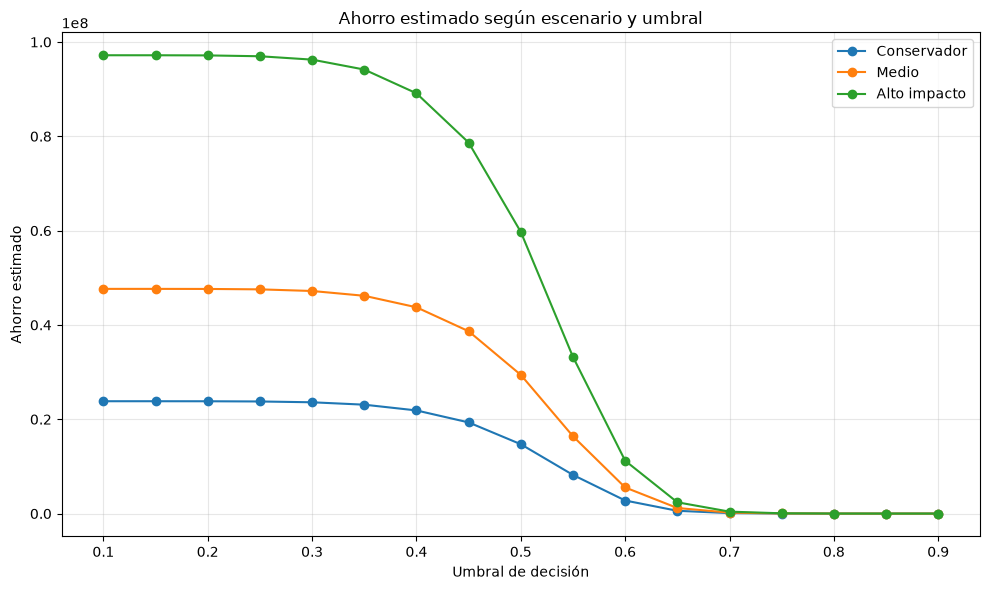

In [16]:
plt.figure(figsize=(10, 6))

for scenario in business_df["scenario"].unique():
    scenario_df = business_df[business_df["scenario"] == scenario]
    plt.plot(
        scenario_df["threshold"],
        scenario_df["estimated_saving"],
        marker="o",
        label=scenario
    )

plt.title("Ahorro estimado según escenario y umbral")
plt.xlabel("Umbral de decisión")
plt.ylabel("Ahorro estimado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIGURES_DIR}/business_scenarios_saving.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Selección del mejor umbral por escenario según ahorro estimado
best_business_thresholds = (
    business_df.sort_values(["scenario", "estimated_saving"], ascending=[True, False])
    .groupby("scenario")
    .head(1)
    .reset_index(drop=True)
)

best_business_thresholds.to_csv(f"{OUTPUT_METRICS_DIR}/best_business_thresholds.csv", index=False)
best_business_thresholds

,scenario,threshold,cost_false_negative,cost_false_positive,stockouts_detected,stockouts_missed,false_alerts,alerts_generated,cost_without_model,cost_with_model,estimated_saving
0,Alto impacto,0.1,200,15,514302,0,378198,892500,102860400.0,5672970.0,97187430.0
1,Conservador,0.1,50,5,514302,0,378198,892500,25715100.0,1890990.0,23824110.0
2,Medio,0.1,100,10,514302,0,378198,892500,51430200.0,3781980.0,47648220.0


## 11. Priorización operativa: top N% de mayor riesgo

En lugar de convertir todas las probabilidades en una decisión binaria, una empresa podría utilizar el modelo para priorizar revisiones.

Por ejemplo:

- Revisar el 10% de casos con mayor probabilidad de stockout.
- Revisar el 20% de mayor riesgo.
- Revisar el 30% de mayor riesgo.

Este enfoque puede ser más realista cuando los recursos operativos son limitados.

In [18]:
top_percentages = [0.05, 0.10, 0.20, 0.30]
prioritization_results = []

pred_ranked = predictions.copy().sort_values("y_proba", ascending=False).reset_index(drop=True)
total_stockouts = pred_ranked["y_true"].sum()

for pct in top_percentages:
    n_cases = int(len(pred_ranked) * pct)
    selected = pred_ranked.head(n_cases)
    detected_stockouts = selected["y_true"].sum()
    capture_rate = detected_stockouts / total_stockouts if total_stockouts > 0 else 0
    alert_precision = detected_stockouts / n_cases if n_cases > 0 else 0
    
    prioritization_results.append({
        "top_percentage": pct,
        "reviewed_cases": n_cases,
        "detected_stockouts": int(detected_stockouts),
        "total_stockouts": int(total_stockouts),
        "capture_rate": capture_rate,
        "alert_precision": alert_precision
    })

prioritization_df = pd.DataFrame(prioritization_results)
prioritization_df.to_csv(f"{OUTPUT_METRICS_DIR}/risk_prioritization.csv", index=False)
prioritization_df

,top_percentage,reviewed_cases,detected_stockouts,total_stockouts,capture_rate,alert_precision
0,0.05,44625,30920,514302,0.060120,0.692885
1,0.10,89250,61641,514302,0.119854,0.690655
2,0.20,178500,121358,514302,0.235966,0.679877
3,0.30,267750,178950,514302,0.347947,0.668347


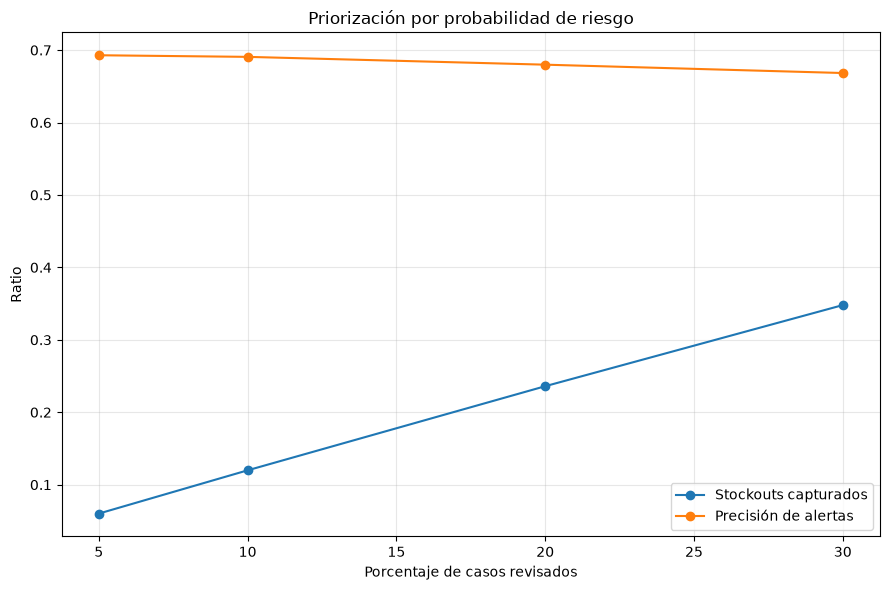

In [19]:
plt.figure(figsize=(9, 6))
plt.plot(prioritization_df["top_percentage"] * 100, prioritization_df["capture_rate"], marker="o", label="Stockouts capturados")
plt.plot(prioritization_df["top_percentage"] * 100, prioritization_df["alert_precision"], marker="o", label="Precisión de alertas")
plt.title("Priorización por probabilidad de riesgo")
plt.xlabel("Porcentaje de casos revisados")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_FIGURES_DIR}/risk_prioritization.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Resumen ejecutivo para el README

Esta sección genera un pequeño resumen con los principales resultados técnicos y de negocio para reutilizar en el README del repositorio.

In [21]:
best_scenario = best_business_thresholds.iloc[0] if len(best_business_thresholds) > 0 else None

readme_summary = []
readme_summary.append("# Resumen de explicabilidad y métricas de negocio")
readme_summary.append("")
readme_summary.append("## Métricas técnicas del modelo final")
for metric, value in final_metrics.items():
    readme_summary.append(f"- {metric}: {value:.4f}")

readme_summary.append("")
readme_summary.append("## Interpretación operativa")
readme_summary.append(f"- Stockouts correctamente detectados: {TP}")
readme_summary.append(f"- Stockouts no detectados: {FN}")
readme_summary.append(f"- Alertas falsas generadas: {FP}")

if not feature_importance_df.empty:
    readme_summary.append("")
    readme_summary.append("## Variables más relevantes")
    for _, row in feature_importance_df.head(5).iterrows():
        readme_summary.append(f"- {row['feature']}: {row['importance']:.4f}")

readme_summary.append("")
readme_summary.append("## Nota metodológica")
readme_summary.append(
    "Las métricas de negocio se han calculado mediante escenarios simulados, ya que no se dispone de costes reales de rotura de stock ni de costes internos de revisión de alertas. "
    "Por tanto, los valores deben interpretarse como una estimación orientativa del potencial del modelo y no como un impacto económico real validado."
)

summary_text = "\n".join(readme_summary)

summary_path = f"{OUTPUT_REPORTS_DIR}/explainability_business_summary.md"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(f"Resumen guardado en: {summary_path}")
print(summary_text)

Resumen guardado en: ../outputs/reports/explainability_business_summary.md
# Resumen de explicabilidad y métricas de negocio

## Métricas técnicas del modelo final
- accuracy: 0.5725
- precision: 0.6351
- recall: 0.6067
- f1_score: 0.6206
- roc_auc: 0.5890

## Interpretación operativa
- Stockouts correctamente detectados: 312044
- Stockouts no detectados: 202258
- Alertas falsas generadas: 179268

## Variables más relevantes
- rolling_mean_14: 1.6194
- rolling_mean_30: 0.9024
- rolling_mean_7: 0.8530
- sales: 0.3797
- trend_7_30: 0.2235

## Nota metodológica
Las métricas de negocio se han calculado mediante escenarios simulados, ya que no se dispone de costes reales de rotura de stock ni de costes internos de revisión de alertas. Por tanto, los valores deben interpretarse como una estimación orientativa del potencial del modelo y no como un impacto económico real validado.


## 13. Conclusiones del análisis

El modelo permite traducir una predicción técnica en una herramienta potencial de priorización operativa. Su uso más realista no sería automatizar decisiones de reposición de forma directa, sino generar una lista priorizada de casos con mayor riesgo para revisión por parte de equipos de planificación, aprovisionamiento o gestión logística.

La utilidad del sistema dependerá del equilibrio entre:

- La capacidad de detectar stockouts reales.
- El volumen de alertas falsas asumible por el negocio.
- El coste real de una rotura de stock.
- El coste operativo de revisar alertas.

Dado que el dataset no contiene información real de inventario, nivel de servicio, penalizaciones contractuales ni costes logísticos, las conclusiones económicas deben considerarse simuladas y orientativas. En una versión productiva sería necesario validar estos supuestos con datos reales de negocio.